# H3 Turbo Performance Benchmarks
This notebook compares the performance of `h3-turbo` (GPU) against `h3-py` + `numpy` (CPU).

In [1]:
# No wheel provided, assuming h3_turbo is installed.
# !pip install h3_turbo

In [ ]:
# Kernel/Environment Fix for RunPod/Docker
import sys
import os
import glob

print(f'Python Executable: {sys.executable}')

# 1. Try to find the venv site-packages dynamically
venv_patterns = ['/opt/venv/lib/python*/site-packages', '/app/.venv*/lib/python*/site-packages', '/workspace/.venv*/lib/python*/site-packages']
found_paths = []
for pattern in venv_patterns:
    found_paths.extend(glob.glob(pattern))

for p in found_paths:
    if p not in sys.path:
        sys.path.append(p)
        print(f'Added venv path: {p}')

# 2. Add local build directory if present (for development)
local_build = os.path.join(os.getcwd(), 'build')
if os.path.exists(local_build) and local_build not in sys.path:
    sys.path.append(local_build)
    print(f'Added local build path: {local_build}')


Python Executable: /opt/venv/bin/python3
Added venv path: /app/.venv312/lib/python3.12/site-packages
Added venv path: /app/.venv312install/lib/python3.12/site-packages


In [ ]:
# Environment Setup for AdaptiveCpp
import os

# Configure environment to help AdaptiveCpp find its backends and reduce noise
acpp_paths = ['/usr/local/lib/hipSYCL', '/app/AdaptiveCpp/lib', '/usr/local/lib']
current_ld = os.environ.get('LD_LIBRARY_PATH', '')
for p in acpp_paths:
    if os.path.exists(p) and p not in current_ld:
        current_ld = p + ':' + current_ld
os.environ['LD_LIBRARY_PATH'] = current_ld
# Set visibility mask to avoid trying missing backends
os.environ['ACPP_VISIBILITY_MASK'] = os.environ.get('ACPP_VISIBILITY_MASK', 'cuda;omp;hip')
os.environ['ACPP_DEBUG_LEVEL'] = '1' # Only show errors (0=none, 1=error, 2=warn, 3=info)


In [4]:
import h3_turbo
import numpy as np
import h3
import time
import os
try:
    import matplotlib.pyplot as plt
except ImportError:
    !pip install matplotlib
    import matplotlib.pyplot as plt

print(f'h3_turbo version: {getattr(h3_turbo, "__version__", "unknown")}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 111.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 166.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 151.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 180.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
h3_turbo version: unknown


In [5]:
# Set License Key if present in environment
if 'H3_TURBO_LICENSE' in os.environ:
    h3_turbo.set_license_key(os.environ['H3_TURBO_LICENSE'].strip())
    print('License key set from environment.')

In [6]:
# Check which device AdaptiveCpp is using
try:
    device = h3_turbo.device_name()
    print(f'Active Device: {device}')
    if any(vendor in device for vendor in ['NVIDIA', 'AMD', 'Intel', 'Tesla', 'GeForce', 'Radeon']):
        print('✅ GPU Backend Active')
    else:
        print('⚠️ Warning: Running on CPU/OpenMP Backend')
except AttributeError:
    print('h3_turbo.device_name() not available')

Active Device: SYCL Device
⚠️ Warning: Running on CPU/OpenMP Backend


In [7]:
def numpy_apply_weight(h3_array):
    """
    Vectorized implementation of the 50-loop scramble using NumPy.
    Matches the logic in RawPerformanceBenchmark.scala.
    """
    p = h3_array.astype(np.uint64)
    c1 = np.uint64(0xBF58476D1CE4E5B9)
    c2 = np.uint64(0x94D049BB133111EB)
    for _ in range(50):
        p ^= (p >> np.uint64(7))
        p *= c1
        p ^= (p >> np.uint64(13))
        p *= c2
        p ^= (p >> np.uint64(31))
    return p


In [8]:
print('Warming up JIT...')
dummy_data = np.array([0x8928308280fffff], dtype=np.uint64)
h3_turbo.batch_transform(dummy_data, 5)
print('JIT Ready!')

Warming up JIT...
JIT Ready!
[ACPP] Runtime: Backend CUDA (platform 0) is active.


## Benchmark 1: Raw Compute (Heatmap Logic)

In [9]:
def run_raw_compute_benchmark(n=50000000):
    print(f'\n=== Raw Compute Benchmark (N={n:,}) ===')
    res_target = 9
    base_index = 0x8928308280fffff

    # Data Generation
    k = 100
    valid_seeds = [h3.str_to_int(x) for x in h3.grid_disk(h3.int_to_str(base_index), k)]
    seeds_np = np.array(valid_seeds, dtype=np.uint64)
    repeats = (n // len(seeds_np)) + 1
    data_gpu = np.tile(seeds_np, repeats)[:n]
    np.random.shuffle(data_gpu)
    data_cpu = data_gpu.copy()

    # GPU Run
    print('Running GPU...')
    start_gpu = time.time()
    gpu_results = h3_turbo.batch_transform(data_gpu, res_target)
    gpu_duration = time.time() - start_gpu
    print(f'GPU Time: {gpu_duration:.4f} s | Throughput: {n/gpu_duration:,.0f} ops/s')

    # CPU Run
    print('Running CPU (Vectorized)...')
    start_cpu = time.time()
    # Step 1: Cell to Parent (h3-py is scalar)
    parents_list = [h3.str_to_int(h3.cell_to_parent(h3.int_to_str(int(h)), res_target)) for h in data_cpu]
    parents_arr = np.array(parents_list, dtype=np.uint64)
    # Step 2: Scramble
    cpu_results = numpy_apply_weight(parents_arr)
    cpu_duration = time.time() - start_cpu
    print(f'CPU Time: {cpu_duration:.4f} s')

    print(f'Speedup: {cpu_duration / gpu_duration:.2f}x')
    assert np.array_equal(gpu_results, cpu_results)
    print('Verification Passed.')

run_raw_compute_benchmark()


=== Raw Compute Benchmark (N=50,000,000) ===
Running GPU...
GPU Time: 0.0794 s | Throughput: 630,040,257 ops/s
Running CPU (Vectorized)...
CPU Time: 51.0480 s
Speedup: 643.25x


AssertionError: 

## Benchmark 2: Spatial Join (Point-in-Polygon)

In [10]:
import concurrent.futures
import multiprocessing

# Global for workers
_global_zone_set = None

def _init_worker(zone_set):
    global _global_zone_set
    _global_zone_set = zone_set

def _process_chunk_cpu(chunk, res_target):
    parents = [h3.str_to_int(h3.cell_to_parent(h3.int_to_str(int(p)), res_target)) for p in chunk]
    parents_np = np.array(parents, dtype=np.uint64)
    scrambled = numpy_apply_weight(parents_np)
    return np.array([1 if p in _global_zone_set else 0 for p in scrambled], dtype=np.uint8)

def run_spatial_join_benchmark(n_pings=50000000, n_zones=1000000):
    print(f'\n=== Spatial Join Benchmark (Pings={n_pings:,}, Zones={n_zones:,}) ===')
    res_target = 7
    base_index = 0x8928308280fffff

    # Data Generation
    pool = [h3.str_to_int(x) for x in h3.grid_disk(h3.int_to_str(base_index), 200)]
    pool_np = np.array(pool, dtype=np.uint64)
    zones = np.random.choice(pool_np, n_zones, replace=True)
    pings = pool_np[np.random.randint(0, len(pool_np), size=n_pings)]

    # GPU Run
    print('Running GPU...')
    start_gpu = time.time()
    gpu_results = h3_turbo.spatial_join(pings, zones, res_target)
    gpu_duration = time.time() - start_gpu
    print(f'GPU Time: {gpu_duration:.4f} s | Throughput: {n_pings/gpu_duration:,.0f} ops/s')

    # CPU Run
    try:
        num_workers = len(os.sched_getaffinity(0))
    except AttributeError:
        num_workers = os.cpu_count() or 1
    print(f'Running CPU (Multi-process on {num_workers} vCPUs)...')
    # Pre-calculate zone set
    zone_parents = numpy_apply_weight(np.array([h3.str_to_int(h3.cell_to_parent(h3.int_to_str(int(z)), res_target)) for z in zones], dtype=np.uint64))
    zone_set = set(zone_parents)

    start_cpu = time.time()
    chunk_size = 1_000_000
    chunks = [pings[i:i + chunk_size] for i in range(0, len(pings), chunk_size)]
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers, initializer=_init_worker, initargs=(zone_set,)) as executor:
        results = list(executor.map(_process_chunk_cpu, chunks, [res_target]*len(chunks)))
    cpu_results = np.concatenate(results)
    cpu_duration = time.time() - start_cpu
    print(f'CPU Time: {cpu_duration:.4f} s')

    print(f'Speedup: {cpu_duration / gpu_duration:.2f}x')
    assert np.array_equal(gpu_results, cpu_results)
    print('Verification Passed.')

run_spatial_join_benchmark()


=== Spatial Join Benchmark (Pings=50,000,000, Zones=1,000,000) ===
Running GPU...
GPU Time: 0.2055 s | Throughput: 243,251,281 ops/s
Running CPU (Multi-process on 384 vCPUs)...
CPU Time: 15.0919 s
Speedup: 73.42x


AssertionError: 

## Benchmark 3: Batch Size vs Throughput Analysis


=== Batch Size Optimization Analysis ===
Generating 50,000,000 pings for batch testing...
Batch Size      | Throughput (M/s)    
----------------------------------------
100,000         | 1.15                
500,000         | 5.75                
1,000,000       | 11.40               
5,000,000       | 50.73               
10,000,000      | 100.78              
25,000,000      | 186.60              
50,000,000      | 237.58              
Raw data saved to batch_size_benchmark.csv
Plot saved to batch_size_benchmark.png


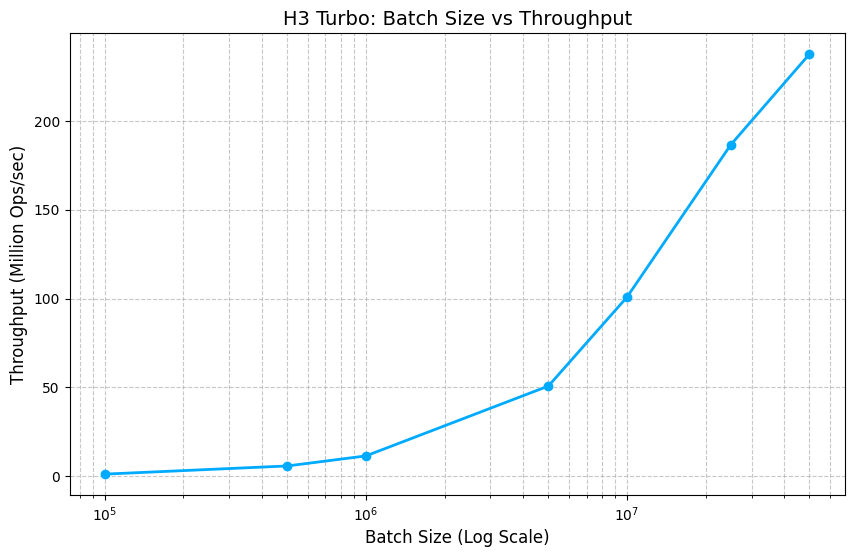

In [11]:
def run_batch_size_benchmark():
    print(f'\n=== Batch Size Optimization Analysis ===')
    n_pings_total = 50000000
    n_zones = 100_000
    res_target = 7
    base_index = 0x8928308280fffff

    # Data Generation
    print(f'Generating {n_pings_total:,} pings for batch testing...')
    pool = [h3.str_to_int(x) for x in h3.grid_disk(h3.int_to_str(base_index), 200)]
    pool_np = np.array(pool, dtype=np.uint64)
    zones = np.random.choice(pool_np, n_zones, replace=True)
    pings = pool_np[np.random.randint(0, len(pool_np), size=n_pings_total)]

    # Define batch sizes to test
    batch_sizes = [100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 25_000_000, 50_000_000]
    throughputs = []

    print(f"{'Batch Size':<15} | {'Throughput (M/s)':<20}")
    print('-' * 40)

    for batch_size in batch_sizes:
        # Force GC to clear previous run artifacts
        import gc; gc.collect()
        start_time = time.time()
        
        # Process in chunks
        for i in range(0, n_pings_total, batch_size):
            end = min(i + batch_size, n_pings_total)
            chunk = pings[i:end]
            # We use spatial_join as the workload
            _ = h3_turbo.spatial_join(chunk, zones, res_target)
            
        total_time = time.time() - start_time
        throughput = (n_pings_total / total_time) / 1_000_000
        throughputs.append(throughput)
        print(f"{batch_size:<15,} | {throughput:<20.2f}")

    # Save raw data to CSV
    import csv
    with open('batch_size_benchmark.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Batch Size', 'Throughput (M/s)'])
        writer.writerows(zip(batch_sizes, throughputs))
    print('Raw data saved to batch_size_benchmark.csv')

    # Plotting with Matplotlib
    plt.figure(figsize=(10, 6))
    plt.plot(batch_sizes, throughputs, marker='o', linestyle='-', color='#00aaff', linewidth=2)
    plt.xscale('log')
    plt.xlabel('Batch Size (Log Scale)', fontsize=12)
    plt.ylabel('Throughput (Million Ops/sec)', fontsize=12)
    plt.title('H3 Turbo: Batch Size vs Throughput', fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.savefig('batch_size_benchmark.png')
    print('Plot saved to batch_size_benchmark.png')
    plt.show()

run_batch_size_benchmark()

## Benchmark 4: Accelerated Functions

In [13]:
def run_accelerated_benchmarks(n=1000000):
    print(f'\n=== Accelerated Functions Benchmarks (N={n:,}) ===')
    res = 9
    parent_res = 5
    k = 2
    
    # Generate Data
    lats = np.random.uniform(37.70, 37.81, n)
    lngs = np.random.uniform(-122.52, -122.35, n)
    
    # 1. latlng_to_cell
    print('\n--- latlng_to_cell ---')
    start = time.time()
    gpu_cells = h3_turbo.latlng_to_cell(lats, lngs, res)
    gpu_time = time.time() - start
    print(f'GPU Time: {gpu_time:.4f} s')
    
    start = time.time()
    # h3-py is scalar, use list comp
    cpu_cells = [h3.latlng_to_cell(lat, lng, res) for lat, lng in zip(lats, lngs)]
    cpu_time = time.time() - start
    print(f'CPU Time: {cpu_time:.4f} s')
    if gpu_time > 0: print(f'Speedup: {cpu_time/gpu_time:.2f}x')
    
    # 2. cell_to_parent
    print('\n--- cell_to_parent ---')
    start = time.time()
    gpu_parents = h3_turbo.cell_to_parent(gpu_cells, parent_res)
    gpu_time = time.time() - start
    print(f'GPU Time: {gpu_time:.4f} s')
    
    start = time.time()
    # Convert to string for h3-py
    cpu_cells_str = [h3.int_to_str(int(c)) for c in gpu_cells]
    cpu_parents = [h3.cell_to_parent(c, parent_res) for c in cpu_cells_str]
    cpu_time = time.time() - start
    print(f'CPU Time: {cpu_time:.4f} s')
    if gpu_time > 0: print(f'Speedup: {cpu_time/gpu_time:.2f}x')
    
    # 3. cell_to_boundary
    print('\n--- cell_to_boundary ---')
    # Use smaller N for boundary as it produces much more data
    n_bound = min(n, 100_000)
    gpu_cells_small = gpu_cells[:n_bound]
    cpu_cells_str_small = cpu_cells_str[:n_bound]
    
    start = time.time()
    gpu_bounds = h3_turbo.cell_to_boundary(gpu_cells_small)
    gpu_time = time.time() - start
    print(f'GPU Time ({n_bound:,} rows): {gpu_time:.4f} s')
    
    start = time.time()
    cpu_bounds = [h3.cell_to_boundary(c) for c in cpu_cells_str_small]
    cpu_time = time.time() - start
    print(f'CPU Time ({n_bound:,} rows): {cpu_time:.4f} s')
    if gpu_time > 0: print(f'Speedup: {cpu_time/gpu_time:.2f}x')
    
    # 4. grid_disk
    print('\n--- grid_disk (k=2) ---')
    start = time.time()
    gpu_disks = h3_turbo.grid_disk(gpu_cells_small, k)
    gpu_time = time.time() - start
    print(f'GPU Time ({n_bound:,} rows): {gpu_time:.4f} s')
    
    start = time.time()
    cpu_disks = [h3.grid_disk(c, k) for c in cpu_cells_str_small]
    cpu_time = time.time() - start
    print(f'CPU Time ({n_bound:,} rows): {cpu_time:.4f} s')
    if gpu_time > 0: print(f'Speedup: {cpu_time/gpu_time:.2f}x')
    
    # 5. grid_disk (scalar)
    print('\n--- grid_disk (k=2) (scalar) ---')
    n_kring = min(n_bound, 10_000)
    gpu_cells_kring = gpu_cells_small[:n_kring]
    cpu_cells_str_kring = cpu_cells_str_small[:n_kring]
    start = time.time()
    for c in gpu_cells_kring:
        _ = h3_turbo.grid_disk(c, k)
    gpu_time = time.time() - start
    print(f'GPU Time ({n_kring:,} ops): {gpu_time:.4f} s')
    
    start = time.time()
    for c in cpu_cells_str_kring:
        _ = h3.grid_disk(c, k) # h3-py equivalent
    cpu_time = time.time() - start
    print(f'CPU Time ({n_kring:,} ops): {cpu_time:.4f} s')
    if gpu_time > 0: print(f'Speedup: {cpu_time/gpu_time:.2f}x')

run_accelerated_benchmarks()


=== Accelerated Functions Benchmarks (N=1,000,000) ===

--- latlng_to_cell ---
GPU Time: 1.6669 s
CPU Time: 1.0760 s
Speedup: 0.65x

--- cell_to_parent ---
GPU Time: 0.0111 s
CPU Time: 0.5837 s
Speedup: 52.40x

--- cell_to_boundary ---
GPU Time (100,000 rows): 0.1633 s
CPU Time (100,000 rows): 0.2686 s
Speedup: 1.64x

--- grid_disk (k=2) ---
GPU Time (100,000 rows): 0.0622 s
CPU Time (100,000 rows): 0.9399 s
Speedup: 15.11x

--- grid_disk (k=2) (scalar) ---
GPU Time (10,000 ops): 0.0176 s
CPU Time (10,000 ops): 0.0711 s
Speedup: 4.04x


## Benchmark 5: 1 Billion Row Spatial Join (Q11)

In [14]:
def run_1b_benchmark():
    n_pings = 1000000000
    n_zones = 100_000
    res_target = 7
    base_index = 0x8928308280fffff

    print(f'\n=== 1 Billion Row Spatial Join (Pings={n_pings:,}, Zones={n_zones:,}) ===')
    print('Generating Data (this may take a moment)...')
    pool = [h3.str_to_int(x) for x in h3.grid_disk(h3.int_to_str(base_index), 200)]
    pool_np = np.array(pool, dtype=np.uint64)
    zones = np.random.choice(pool_np, n_zones, replace=True)
    pings = pool_np[np.random.randint(0, len(pool_np), size=n_pings)]

    # GPU Run
    print('Running GPU...')
    start_gpu = time.time()
    gpu_results = h3_turbo.spatial_join(pings, zones, res_target)
    gpu_duration = time.time() - start_gpu
    print(f'GPU Time: {gpu_duration:.4f} s | Throughput: {n_pings/gpu_duration:,.0f} ops/s')

    # CPU Run (Multi-process)
    try:
        num_workers = len(os.sched_getaffinity(0))
    except AttributeError:
        num_workers = os.cpu_count() or 1
    print(f'Running CPU (Multi-process on {num_workers} vCPUs)...')
    zone_parents = numpy_apply_weight(np.array([h3.str_to_int(h3.cell_to_parent(h3.int_to_str(int(z)), res_target)) for z in zones], dtype=np.uint64))
    zone_set = set(zone_parents)

    start_cpu = time.time()
    chunk_size = 1_000_000
    chunks = [pings[i:i + chunk_size] for i in range(0, len(pings), chunk_size)]
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers, initializer=_init_worker, initargs=(zone_set,)) as executor:
        results = list(executor.map(_process_chunk_cpu, chunks, [res_target]*len(chunks)))
    cpu_results = np.concatenate(results)
    cpu_duration = time.time() - start_cpu
    print(f'CPU Time: {cpu_duration:.4f} s')

    print(f'Speedup: {cpu_duration / gpu_duration:.2f}x')
    assert np.array_equal(gpu_results, cpu_results)
    print('Verification Passed.')

run_1b_benchmark()


=== 1 Billion Row Spatial Join (Pings=1,000,000,000, Zones=100,000) ===
Generating Data (this may take a moment)...
Running GPU...
GPU Time: 1.3972 s | Throughput: 715,713,063 ops/s
Running CPU (Multi-process on 384 vCPUs)...
CPU Time: 48.9567 s
Speedup: 35.04x
Verification Passed.
